In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
from pymeos.db.psycopg import MobilityDB
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
import numpy as np
import zipfile
warnings.simplefilter("ignore")
import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq, TGeomPointInst
pymeos.pymeos_initialize()

Here the size of the dataset can be chosen.

In [14]:
chosen_size = 'small'
sizes = {'small': 1000000, 'medium': 5000000, 'big': 20000000}

zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

n_rows = sizes[chosen_size]


In [15]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=n_rows)

    rows = list(df.itertuples(index=False, name=None))
    df = pd.DataFrame(rows, columns=['t', 'mmsi', 'latitude', 'longitude'])
    df = df.drop_duplicates(subset=['t', 'mmsi'], keep='first')
    global nb_points
    nb_points = df.shape[0]

# extraction()

In [16]:
def construction_from_instants():

    df2 = df.sort_values(['mmsi', 't'])
    df2['geometry'] = [Point(lon, lat) for lon, lat in zip(df2['longitude'], df2['latitude'])]

    df2["point"] = df2.apply(
        lambda row: TGeomPointInst(
            point=row["geometry"],
            timestamp=row["t"],
            srid=4326,
        ),
        axis=1,
    )

    global trajectories_with2
    trajectories_with2 = (df2.groupby("mmsi")
        .aggregate({"point": lambda traj: TGeomPointSeq.from_instants(traj, upper_inc=True)})
        .rename({"point": "trajectory"}, axis=1)
    )

# construction_from_instants()

In [ ]:
def construction_from_arrays():

    df3 = df.sort_values(by=['mmsi', 't'])
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with3
    t3 = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['longitude'].values, 
            y = traj['latitude'].values,
            srid = 25832,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_with3 = t3['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')

# construction_from_arrays()

In [18]:
import time
from memory_profiler import memory_usage
results = {}

def benchmark_cpu_time(f, n=5):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    # times.pop(times.index(max(times))) # if you want to remove the max and min times
    # times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)

    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


benchmark_cpu_time(extraction)
benchmark_cpu_time(construction_from_instants)
benchmark_cpu_time(construction_from_arrays)

Function extraction:
CPU time over 5 runs: 1.794300 sec ± 0.014614 sec
Memory usage : 235.14 MiB

Function construction_from_instants:
CPU time over 5 runs: 9.511510 sec ± 0.153333 sec
Memory usage : 44.75 MiB

Function construction_from_arrays:
CPU time over 5 runs: 3.412672 sec ± 0.100976 sec
Memory usage : 0.12 MiB



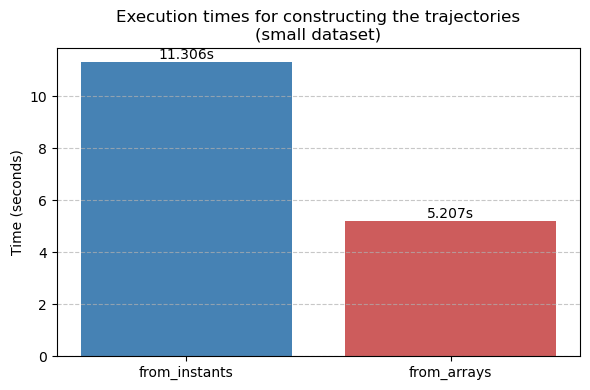

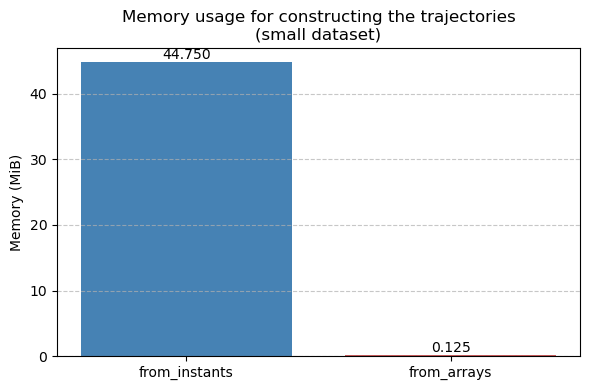

In [20]:
times = [results['extraction'][0]+ results['construction_from_instants'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0]]
mem = [results['construction_from_instants'][1], results['construction_from_arrays'][1]]
labels = ['from_instants', 'from_arrays']


plt.figure(figsize=(6, 4))
bars = plt.bar(labels, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, mem, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()